In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import ParameterGrid

import sys
from itertools import product
sys.path.append('../../')
import src.forecasting.simulations      as sim
import src.fda.kde.estimators           as kde
import src.fda.transformations.lqdt     as lqdt
import src.fda.dfpc              as dfpc

In [2]:
import asgl

In [3]:
# Define scenarios
gas_params = {
    # "scenario_1": {
    #     "Description": "Location-driven ($m_t$)",
    #     "alpha": np.diag([0.08, 0.01, 0.01]),
    #     "beta": np.diag([0.90, 0.95, 0.95]),
    # },
    # "scenario_2": {
    #     "Description": "Scale-driven ($\sigma_t$)",
    #     "alpha": np.diag([0.01, 0.08, 0.01]),
    #     "beta": np.diag([0.95, 0.90, 0.95]),
    # },
    # "scenario_3": {
    #     "Description": "Shape-driven ($\eta_t$)",
    #      "alpha": np.diag([0.01, 0.01, 0.08]),
    #       "beta": np.diag([0.95, 0.95, 0.90])
    # },
    "scenario_4": {
        "Description": "Mixture",
        "alpha": np.diag([0.04, 0.06, 0.04]),
        "beta": np.diag([0.92, 0.95, 0.94]),
    }
}

distribution_params = {
    "nu": [3]
}

keys = ["scenario", "nu"]
values = [list(gas_params.keys()), distribution_params["nu"]]

param_grid = []

for scenario, nu in product(*values):
    gas_cfg = gas_params[scenario]

    param_grid.append({
        "scenario": "___nu=".join([scenario, str(nu)]),
        "nu": nu,
        "alpha": gas_cfg["alpha"],
        "beta": gas_cfg["beta"]    
})

In [4]:
# grid for densities
x = np.linspace(-40, 40, 5001)
# number of curves (densities)
T = 301
# number of simulations (f_{N_REP,1},...,f_{N_REP,T})
N_REPS = 10
# number of samples from each f_t density
N_SAMPLES = 288

total = len(param_grid) * N_REPS

In [5]:
sim_database = {}
total = len(param_grid) * N_REPS

for params in param_grid:
    scenario = params["scenario"]
    # Initialize scenario level
    sim_database[scenario] = {
        "params": params,
        "replications": {}
    }
    
    for n_rep in range(N_REPS):
        # 1. Setup Model and Simulate
        gm = sim.GasModel(alpha=params["alpha"], beta=params["beta"], nu=params["nu"])
        sim_results = gm.simulate(T=T, burn_in=300)
        
        # 2. Get Theoretical Densities
        sim_density = gm.conditional_densities(grid=x, theta_path=sim_results["theta"])
        dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=T, freq="D")
        sim_density.columns = dates
        
        # 3. Generate Samples Efficiently
        # Collect arrays first, then create DataFrame once
        samples_list = []
        for i in range(len(sim_results["theta"])):
            # Draw n samples for the theta at time i
            sample = gm.rvs(n=N_SAMPLES, theta=sim_results["theta"][i])
            samples_list.append(sample)
        
        # Create DataFrame: each column is a time step, each row a sample
        df_samples = pd.DataFrame(np.array(samples_list).T, columns=dates)
        
        # 4. Store in Database
        sim_database[scenario]["replications"][n_rep] = {
            "theta": sim_results["theta"],
            "densities": sim_density,
            "samples": df_samples
        }

In [6]:
returns_df = sim_database['scenario_4___nu=3']['replications'][0]['samples']
# bandwidths
kde_bw_params = {"method": "rot", "kernel": "gaussian", "sigma_robust":False}

df_h = kde.df_bandwidth_selector(returns_df, **kde_bw_params)    
kde_params = {k: v for k, v in kde_bw_params.items() if k in ['kernel', 'df']}

# kdes
df_grids, df_densities = kde.df_to_kde(
    X=returns_df, 
    h=df_h, 
    normalize_densities=False,
    **kde_params
)

<Axes: >

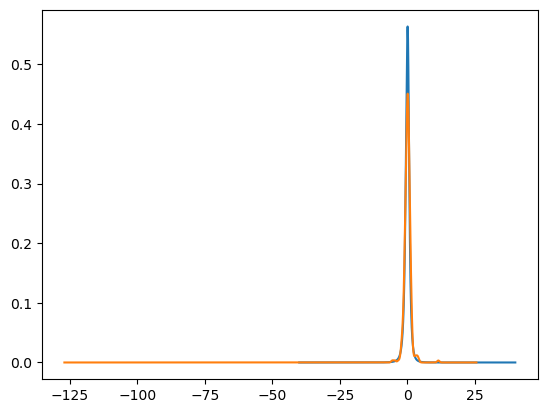

In [7]:
i = 100
sim_database['scenario_4___nu=3']['replications'][0]["densities"].iloc[:,i].plot(legend=False)
df_densities.iloc[:,i].plot(legend=False)

In [8]:
mlqdt = lqdt.mLQDT()
model_lqd = mlqdt.transform(
    densities=df_densities,
    densities_supports=df_grids, 
    verbose=False
    )
# model_lqd.densities_to_lqdensities(verbose=False)

# 2. L2 Expansion (K_dFPC)
Y_t  = model_lqd.lqd.copy()
Y_t.index = model_lqd.lqd_support

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


<Axes: >

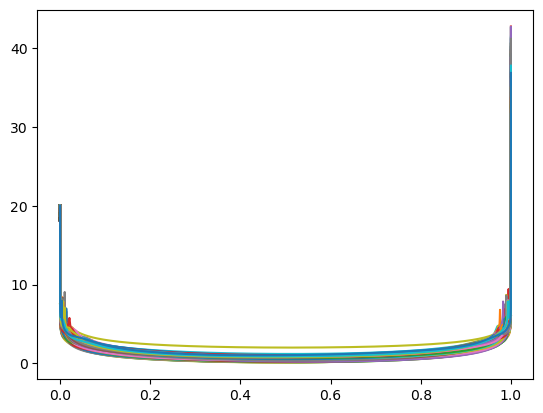

In [9]:
Y_t.plot(legend=False)

In [10]:
KdFPC_kwargs = {
    "p": 5,
    "dimension": 3
}

In [11]:
Y_train, Y_test = Y_t.iloc[:,:-1], Y_t.iloc[:,-1]

In [12]:
lqd_values  = Y_train.values
lqd_support = Y_train.index.values

KdFPC_kwargs.update({
    "u": lqd_support,
    "du": model_lqd.du
})

model_kdfpc = dfpc.K_dFPC(lqd_values)
model_kdfpc.fit(**KdFPC_kwargs)

In [13]:
etas = model_kdfpc.etahat
etas

,scores_1,scores_2,scores_3
0,0.101901,0.004280,-0.056771
1,0.094446,0.185454,-0.013297
2,0.051546,0.138796,-0.013438
3,0.029193,0.095909,0.045342
4,0.077662,0.017599,0.041245
...,...,...,...
295,-0.260723,0.200025,-0.005665
296,-0.218007,-0.023450,-0.022945
297,-0.165285,0.103951,0.021787
298,-0.241899,0.059063,-0.048595


In [14]:
import numpy as np

from sklearn.linear_model import Ridge, ElasticNet

class ScoreForecaster:
    """
    Forecast FPC scores from intraday observations.

    The model estimates

        eta_{t,j} = H_j(z_{t-1}, ..., z_{t-lag})

    separately for each score j.

    Parameters
    ----------
    model : {"ridge", "elasticnet", "lightgbm"}
        Regression algorithm.

    lag : int, default=1
        Number of previous days used as predictors.

    model_params : dict, optional
        Parameters passed to the regression model.

    Notes
    -----
    If each day contains m intraday observations and lag=L,
    then each predictor vector has dimension

        m * L

    Example
    -------
    Suppose

        samples.shape = (300, 288)
        scores.shape  = (300, 3)

    Then

        forecaster.fit(samples, scores)

    learns

        eta_t = H(z_{t-1})

    and

        forecaster.predict_next(samples)

    returns a 3-dimensional score forecast.
    """

    def __init__(
        self,
        model="ridge",
        lag=1,
        model_params=None
    ):

        self.model_name = model.lower()
        self.lag = lag
        self.model_params = model_params or {}

        self.models_ = None
        self.n_components_ = None

    def _build_model(self):

        if self.model_name == "ridge":

            return Ridge(
                alpha=self.model_params.get(
                    "alpha", 1.0
                )
            )

        elif self.model_name == "elasticnet":

            return ElasticNet(
                alpha=self.model_params.get(
                    "alpha", 1.0
                ),
                l1_ratio=self.model_params.get(
                    "l1_ratio", 0.5
                ),
                max_iter=self.model_params.get(
                    "max_iter", 10000
                )
            )

        raise ValueError(
            f"Unknown model '{self.model_name}'."
        )

    def _build_design_matrix(
        self,
        samples,
        scores
    ):
        """
        Construct lagged intraday predictors.

        Parameters
        ----------
        samples : ndarray (T, m)
            Intraday observations.

        scores : ndarray (T, d)
            FPC scores.

        Returns
        -------
        X : ndarray
            Predictor matrix.

        Y : ndarray
            Response matrix.
        """

        T, m = samples.shape
        _, d = scores.shape

        X = []
        Y = []

        for t in range(self.lag, T):

            predictors = samples[
                t-self.lag:t
            ].reshape(-1)

            X.append(predictors)

            Y.append(scores[t])

        return (
            np.asarray(X),
            np.asarray(Y)
        )

    def fit(
        self,
        samples,
        scores
    ):
        """
        Fit forecasting models.

        Parameters
        ----------
        samples : ndarray (T, m)
            Intraday observations.

        scores : ndarray (T, d)
            FPC score matrix.

        Returns
        -------
        self
        """

        X, Y = self._build_design_matrix(
            samples,
            scores
        )

        self.n_components_ = Y.shape[1]

        self.models_ = []

        for j in range(self.n_components_):

            model = self._build_model()

            model.fit(
                X,
                Y[:, j]
            )

            self.models_.append(model)

        return self

    def predict_next(
        self,
        samples
    ):
        """
        Forecast next score vector.

        Parameters
        ----------
        samples : ndarray (T, m)

        Returns
        -------
        ndarray (d,)
        """

        x = samples[
            -self.lag:
        ].reshape(1, -1)

        preds = np.zeros(
            self.n_components_
        )

        for j, model in enumerate(
            self.models_
        ):
            preds[j] = model.predict(x)[0]

        return preds.reshape([-1,1])

    def fitted_values(
        self,
        samples,
        scores
    ):
        """
        In-sample fitted score forecasts.

        Returns
        -------
        ndarray (T-lag, d)
        """

        X, _ = self._build_design_matrix(
            samples,
            scores
        )

        preds = np.zeros(
            (
                X.shape[0],
                self.n_components_
            )
        )

        for j, model in enumerate(
            self.models_
        ):
            preds[:, j] = model.predict(X)

        return preds

In [15]:
import numpy as np

from sklearn.linear_model import Ridge, ElasticNet

class ScoreForecaster:
    """
    Forecast FPC scores from intraday observations.

    The model estimates

        eta_{t,j} = H_j(z_{t-1}, ..., z_{t-lag})

    separately for each score j.

    Parameters
    ----------
    model : {"ridge", "elasticnet", "lightgbm"}
        Regression algorithm.

    lag : int, default=1
        Number of previous days used as predictors.

    model_params : dict, optional
        Parameters passed to the regression model.

    Notes
    -----
    If each day contains m intraday observations and lag=L,
    then each predictor vector has dimension

        m * L

    Example
    -------
    Suppose

        samples.shape = (300, 288)
        scores.shape  = (300, 3)

    Then

        forecaster.fit(samples, scores)

    learns

        eta_t = H(z_{t-1})

    and

        forecaster.predict_next(samples)

    returns a 3-dimensional score forecast.
    """

    def __init__(
        self,
        model="ridge",
        lag=1,
        model_params=None
    ):

        self.model_name = model.lower()
        self.lag = lag
        self.model_params = model_params or {}

        self.models_ = None
        self.n_components_ = None

    def _build_model(self):

        if self.model_name == "ridge":

            return Ridge(
                alpha=self.model_params.get(
                    "alpha", 1.0
                )
            )

        elif self.model_name == "elasticnet":
            return ElasticNet(
                alpha=self.model_params.get(
                    "alpha", 0.001
                ),
                l1_ratio=self.model_params.get(
                    "l1_ratio", 0.5
                ),
                max_iter=self.model_params.get(
                    "max_iter", 10000
                )
            )

        elif self.model_name == "adalasso":

            return asgl.Regressor(
                model="lm",
                penalization="alasso",
                lambda1=self.model_params.get("lambda1", 0.01),
                weight_technique=self.model_params.get("weight_technique", "lasso")
            )

        raise ValueError(
            f"Unknown model '{self.model_name}'."
        )

    def _build_design_matrix(
        self,
        samples,
        scores
    ):
        """
        Construct lagged intraday predictors.

        Parameters
        ----------
        samples : ndarray (T, m)
            Intraday observations.

        scores : ndarray (T, d)
            FPC scores.

        Returns
        -------
        X : ndarray
            Predictor matrix.

        Y : ndarray
            Response matrix.
        """

        T, m = samples.shape
        _, d = scores.shape

        X = []
        Y = []

        for t in range(self.lag, T):

            predictors = samples[
                t-self.lag:t
            ].reshape(-1)

            X.append(predictors)

            Y.append(scores[t])

        return (
            np.asarray(X),
            np.asarray(Y)
        )

    def fit(
        self,
        samples,
        scores
    ):
        """
        Fit forecasting models.

        Parameters
        ----------
        samples : ndarray (T, m)
            Intraday observations.

        scores : ndarray (T, d)
            FPC score matrix.

        Returns
        -------
        self
        """

        X, Y = self._build_design_matrix(
            samples,
            scores
        )

        self.n_components_ = Y.shape[1]

        self.models_ = []

        for j in range(self.n_components_):

            model = self._build_model()

            model.fit(
                X,
                Y[:, j]
            )

            self.models_.append(model)

        return self

    def predict_next(
        self,
        samples
    ):
        """
        Forecast next score vector.

        Parameters
        ----------
        samples : ndarray (T, m)

        Returns
        -------
        ndarray (d,)
        """

        x = samples[
            -self.lag:
        ].reshape(1, -1)

        preds = np.zeros(
            self.n_components_
        )

        for j, model in enumerate(
            self.models_
        ):
            preds[j] = model.predict(x)[0]

        return preds.reshape([-1,1])

    def fitted_values(
        self,
        samples,
        scores
    ):
        """
        In-sample fitted score forecasts.

        Returns
        -------
        ndarray (T-lag, d)
        """

        X, _ = self._build_design_matrix(
            samples,
            scores
        )

        preds = np.zeros(
            (
                X.shape[0],
                self.n_components_
            )
        )

        for j, model in enumerate(
            self.models_
        ):
            preds[:, j] = model.predict(X)

        return preds

In [16]:
samples = df_samples.iloc[:, :-1].values

In [17]:
samples

array([[ 0.31840534, -0.20166565, -0.5781897 , ...,  0.08876752,
         0.48885101,  1.09794645],
       [ 0.36817167,  1.01998019,  0.86868922, ..., -1.32205093,
         1.17022974,  0.03782435],
       [ 0.88105241,  0.67689174,  1.37018247, ...,  0.14089468,
        -0.66550303,  0.8497477 ],
       ...,
       [-1.19550614,  0.52521296,  2.00218985, ...,  0.22177704,
         0.4808555 , -1.57449404],
       [-0.26875432, -0.03987055, -1.36026209, ...,  1.93587021,
         0.11000779, -0.28992151],
       [-0.46751748,  0.62959923, -0.1353179 , ..., -0.81591764,
         0.73915815,  0.82800141]], shape=(288, 300))

In [18]:
etas.values

array([[ 1.01900955e-01,  4.28045908e-03, -5.67708345e-02],
       [ 9.44463436e-02,  1.85454343e-01, -1.32968987e-02],
       [ 5.15460532e-02,  1.38795696e-01, -1.34380578e-02],
       [ 2.91933163e-02,  9.59089311e-02,  4.53416256e-02],
       [ 7.76619635e-02,  1.75985413e-02,  4.12450543e-02],
       [-7.12326837e-02,  2.70347993e-02,  1.85435438e-02],
       [-5.96495397e-02,  9.58653872e-02,  3.96498173e-02],
       [-4.73137828e-02, -1.40917172e-02, -1.67306868e-02],
       [-3.16393592e-01,  1.67020959e-01, -1.60305009e-02],
       [-1.31819788e-01,  9.12926618e-02,  4.41604875e-02],
       [-1.15546455e-01,  8.76331408e-02,  2.73303081e-02],
       [-4.08003788e-01,  9.33858128e-03, -6.83291653e-02],
       [ 5.31235684e-02, -7.07487667e-02,  1.89387512e-02],
       [-1.04115733e-01, -7.29283512e-02,  8.11859241e-03],
       [-2.25095218e-01, -7.08765480e-02, -1.31077494e-01],
       [-3.87484806e-01, -2.24239016e-01,  2.07317579e-02],
       [-1.82097080e-01, -5.26302260e-02

In [59]:
forecaster_en = ScoreForecaster(model="ridge", lag=3)
forecaster_en.fit(samples, etas.values)

forecaster_ada = ScoreForecaster(model="adalasso", lag=3)
forecaster_ada.fit(samples, etas.values)

pred_en = forecaster_en.predict_next(samples)
pred_ada = forecaster_ada.predict_next(samples)

print(pred_en)
print(pred_ada)

[[ 2.45693789]
 [-0.17102934]
 [-0.02081561]]
[[1.33614549e+00]
 [9.02986192e-03]
 [2.91360510e-04]]


In [60]:
Y_n_p_1 = model_kdfpc.predict(pred_en)
Y_n_p_1.index = Y_test.index
Y_n_p_1

,0
0.0000,-114.261740
0.0002,6.457590
0.0004,5.895447
0.0006,5.585425
0.0008,5.377530
...,...
0.9992,5.400874
0.9994,5.605913
0.9996,5.912279
0.9998,6.469946


In [61]:
Y_n_p_2 = model_kdfpc.predict(pred_ada)
Y_n_p_2.index = Y_test.index
Y_n_p_2

,0
0.0000,-34.482026
0.0002,6.629356
0.0004,6.074686
0.0006,5.770865
0.0008,5.568890
...,...
0.9992,5.580575
0.9994,5.781284
0.9996,6.083101
0.9998,6.634770


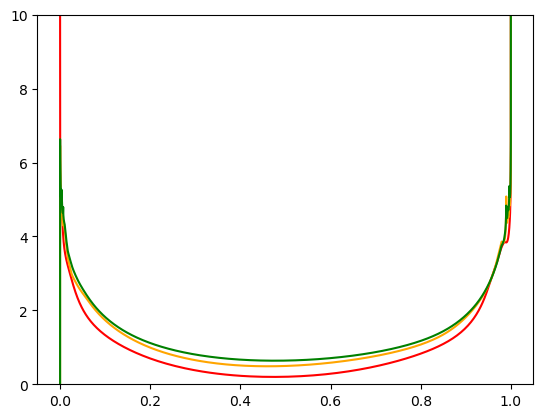

In [66]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(15,5))
Y_test.plot(color="red")
Y_n_p_1.iloc[:,0].plot(color="orange")
Y_n_p_2.iloc[:,0].plot(color="green")
plt.ylim([-0,10])
plt.show()

In [81]:
import numpy as np
import pandas as pd

class SimulationForecaster:
    """
    Time-series forecaster for Probability Density Functions (PDFs).

    This class implements a forecasting pipeline for functional data (densities) 
    by mapping them into a Hilbert space using the Log-Quantile Density (LQD) 
    transformation. It reduces dimensionality via Karhunen-Loève dynamic Functional 
    Principal Component (K-dFPC) Analysis and forecasts the resulting 
    coefficients using a multivariate ScoreForecaster.

    Parameters
    ----------
    kdfpc_kwargs : dict, optional
        Keyword arguments passed to the `dfpc.K_dFPC` model (e.g., n_components).
    forecaster_model : str, default='ridge'
        The underlying model type used by the ScoreForecaster.
    lag : int, default=3
        The number of lags to consider for the score forecaster.

    Attributes
    ----------
    model_lqd : lqdt.mLQDT
        The fitted LQD transformation object containing LQD curves and constants.
    model_kdfpc : dfpc.K_dFPC
        The fitted Functional PCA model.
    score_forecaster : ScoreForecaster
        The fitted multivariate forecaster for PCA scores.
    """
    
    def __init__(self, kdfpc_kwargs=None, forecaster_model="ridge", lag=3):
        self.kdfpc_kwargs = kdfpc_kwargs or {}
        self.forecaster_model = forecaster_model
        self.lag = lag
        
        # Initialized during fitting
        self.returns = None
        self.model_lqd = None
        self.model_kdfpc = None
        self.score_forecaster = None

    def fit(self, Y_train: pd.DataFrame, Y_support: pd.DataFrame, returns: pd.DataFrame):
        """
        Fits the LQD transformation, Functional PCA, and the internal ScoreForecaster.
        """
        self.returns = returns
        # 1. Transform Densities to LQD Space
        mlqdt = lqdt.mLQDT()
        self.model_lqd = mlqdt.transform(
            densities=Y_train,
            densities_supports=Y_support, 
            verbose=False
        )
        
        # 2. Extract L2 Expansion (K_dFPC)
        lqd_values = self.model_lqd.lqd.values
        lqd_support = self.model_lqd.lqd_support
        
        # Use a copy to avoid mutating constructor configurations dynamically
        kdfpc_params = self.kdfpc_kwargs.copy()
        kdfpc_params.update({
            "u": lqd_support,
            "du": self.model_lqd.du
        })
        
        self.model_kdfpc = dfpc.K_dFPC(lqd_values)
        self.model_kdfpc.fit(**kdfpc_params)
        
        # 3. Fit Multivariate Score Forecaster
        scores = self.model_kdfpc.etahat.values.real
        
        self.score_forecaster = ScoreForecaster(
            model=self.forecaster_model,
            lag=self.lag
        )
        self.score_forecaster.fit(returns.values, scores)

        return self

    def predict(self, horizon: int, forecast_index: pd.Index = None) -> dict:
        """
        Forecasts future scores, reconstructs LQD curves, and inverts them back to densities.
        """
        if self.score_forecaster is None:
            raise RuntimeError("The forecaster must be fitted before calling predict.")

        # Build forecasted index labels
        if forecast_index is not None:
            if len(forecast_index) != horizon:
                raise ValueError(f"forecast_index length ({len(forecast_index)}) must match horizon ({horizon})")
            future_dates = forecast_index
        else:
            future_dates = np.arange(horizon)
        
        # 1. Forecast Scores
        k_etahat_fc = self.score_forecaster.predict_next(self.returns.values)
        
        # 2. Reconstruct LQD Curves
        L2_curve_forecast = self.model_kdfpc.predict(k_etahat_fc)
        L2_curve_forecast.columns = future_dates
        
        
        return {
            "future_L2_curves": L2_curve_forecast,
            "future_scores": k_etahat_fc
        }

In [82]:
Y_train, Y_test = df_densities.iloc[:,:-1], df_densities.iloc[:,-1]
Y_supp_train, Y_supp_test = df_grids.iloc[:,:-1], df_grids.iloc[:,-1]
returns_train = df_samples.iloc[:,:-1]

In [93]:

forecaster = SimulationForecaster(kdfpc_kwargs=KdFPC_kwargs)
forecaster.fit(Y_train, Y_supp_train, returns=returns_train)
results = forecaster.predict(horizon=1, forecast_index=Y_test.to_frame().columns)

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [96]:

forecaster = SimulationForecaster(kdfpc_kwargs=KdFPC_kwargs, forecaster_model="elasticnet")
forecaster.fit(Y_train, Y_supp_train, returns=returns_train)
results = forecaster.predict(horizon=1,forecast_index=Y_test.to_frame().columns)
results["future_L2_curves"]

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


,2026-06-01
0,19.954504
1,6.557293
2,6.020766
3,5.731260
4,5.542426
...,...
4996,5.544393
4997,5.733045
4998,6.022386
4999,6.558617
